In [2]:
import pandas as pd

df = pd.read_csv(
    '/content/Resume.csv',
    engine='python',
    on_bad_lines='skip'
)

print(df.columns)

df.head()

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [4]:
nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
df = df[
    [
        'Resume_str',
        'Category'
    ]
]

df.dropna(inplace=True)

df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [6]:
stop_words = set(
    stopwords.words('english')
)

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        text
    )

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

df['Cleaned_Resume'] = df[
    'Resume_str'
].apply(clean_text)

df.head()

,Resume_str,Category,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [7]:
job_description = """
Looking for an AI/ML Engineer with Python,
Machine Learning, Deep Learning,
Data Analysis, TensorFlow,
SQL, Data Visualization,
Problem Solving and Communication Skills.
"""

In [13]:
documents = list(df['Cleaned_Resume'])

documents.append(
    clean_text(job_description)
)

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    documents
)

In [14]:
job_vector = tfidf_matrix[-1]

resume_vectors = tfidf_matrix[:-1]

scores = cosine_similarity(
    resume_vectors,
    job_vector
)

scores = scores.flatten()

results = df.copy()

results['Score'] = scores

In [19]:
ranked_candidates = results.sort_values(
    by='Score',
    ascending=False
)

ranked_candidates[
    [
        'Category',
        'Score'
    ]
].head(10).reset_index(drop=True)

,Category,Score
0,DESIGNER,0.133872
1,INFORMATION-TECHNOLOGY,0.121506
2,INFORMATION-TECHNOLOGY,0.097391
3,INFORMATION-TECHNOLOGY,0.092044
4,INFORMATION-TECHNOLOGY,0.090230
5,INFORMATION-TECHNOLOGY,0.084734
6,INFORMATION-TECHNOLOGY,0.083742
7,DESIGNER,0.076416
8,DESIGNER,0.074527
9,DESIGNER,0.073676


In [20]:
required_skills = [
    'python',
    'machine learning',
    'tensorflow',
    'sql'
]

top_resume = ranked_candidates.iloc[0][
    'Cleaned_Resume'
]

missing_skills = []

for skill in required_skills:

    if skill not in top_resume:

        missing_skills.append(
            skill
        )

print(
    'Missing Skills:',
    missing_skills
)

Missing Skills: ['python', 'machine learning', 'tensorflow', 'sql']


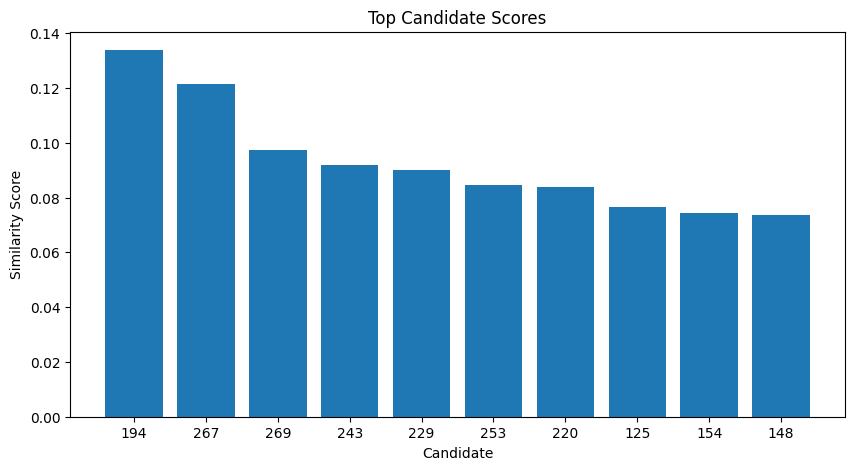

In [21]:
top_10 = ranked_candidates.head(10)

plt.figure(
    figsize=(10,5)
)

plt.bar(
    top_10.index.astype(str),
    top_10['Score']
)

plt.title(
    'Top Candidate Scores'
)

plt.xlabel(
    'Candidate'
)

plt.ylabel(
    'Similarity Score'
)

plt.show()

## Business Insights

1. Resume screening reduces recruiter workload.

2. Candidate ranking speeds up hiring decisions.

3. Skill gap identification helps recruiters identify missing competencies.

4. NLP can automate initial resume shortlisting.

5. Companies can improve hiring efficiency.